In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pathlib
import cv2
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import models, layers

from tensorflow.keras import optimizers
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [3]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/gender_dataset_face"
type(data_dir)

str

In [4]:
data_dir = pathlib.Path(data_dir)
type(data_dir)

pathlib.PosixPath

In [5]:
data_dir.glob("*")

<generator object Path.glob at 0x7a906af39be0>

In [6]:
list(data_dir.glob("*"))

[PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/man')]

In [7]:
list(data_dir.glob("woman/*"))

[PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_898.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1339.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1168.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1207.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1256.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1081.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_913.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1046.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1170.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1187.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_data

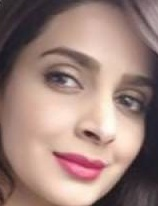

In [8]:
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("woman/*"))[17]))

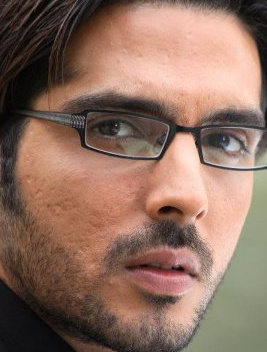

In [9]:
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("man/*"))[30]))

In [10]:
print(len(list(data_dir.glob("woman/*"))))
print(len(list(data_dir.glob("man/*"))))

1134
1173


In [11]:
1134 + 1173

2307

In [12]:
gender_images_dict = {
    'Woman': list(data_dir.glob('woman/*')),
    'Man': list(data_dir.glob('man/*')),
}
gender_labels_dict = {
    'Woman': 0,
    'Man': 1,
}

In [13]:
# X, y = [], []

# for gender, images in gender_images_dict.items():
#     for image in images:
#         img = cv2.imread(image)
#         resized_img = cv2.resize(img,(224,224))
#         resized_img = resized_img.astype("float32")/255
#         resized_img = resized_img.astype("float32")
#         X.append(resized_img)
#         y.append(gender_labels_dict[gender])

In [14]:
# X = np.array(X)
# y = np.array(y)

In [15]:
# np.savez_compressed("/content/drive/MyDrive/Colab Notebooks/gender_dataset.npz", X=X, y=y)

In [3]:
data = np.load("/content/drive/MyDrive/Colab Notebooks/gender_dataset.npz")

X = data["X"]
y = data["y"]

In [4]:
X.shape

(2307, 224, 224, 3)

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1765,
    stratify=y_train,
    random_state=42
)

In [6]:
print("Train:", np.bincount(y_train_final))
print("Validation:", np.bincount(y_val))
print("Test:", np.bincount(y_test))

Train: [793 821]
Validation: [170 176]
Test: [171 176]


class distribution remains consistent across splits

In [7]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode="nearest"
)

train_generator = train_datagen.flow(
    x_train_final,
    y_train_final,
    batch_size=32,
    shuffle=True
)

In [8]:
val_datagen = ImageDataGenerator()

val_generator = val_datagen.flow(
    x_val,
    y_val,
    batch_size=32,
    shuffle=False
)

**Insights:**

Data augmentation was applied to the training data to simulate real-world variations such as slight rotations, shifts, zoom, and lighting changes. This helps the model generalize better and reduces overfitting by exposing it to more diverse facial patterns during training, while validation data remained unchanged to ensure unbiased evaluation.

# A. Custom CNN :-

In [9]:
checkpointer = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Colab Notebooks/gender_detection_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)

In [10]:
cnn_model = models.Sequential()

# Input layer
cnn_model.add(layers.Input(shape=(224, 224, 3)))

# -------- Block 1 --------
cnn_model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
cnn_model.add(layers.BatchNormalization())
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.Dropout(0.20))

# -------- Block 2 --------
cnn_model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
cnn_model.add(layers.BatchNormalization())
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.Dropout(0.25))

# -------- Block 3 --------
cnn_model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model.add(layers.BatchNormalization())
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.Dropout(0.30))

# -------- Block 4 --------
cnn_model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
cnn_model.add(layers.BatchNormalization())
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.Dropout(0.35))

# -------- Classifier --------
cnn_model.add(layers.Flatten())

cnn_model.add(layers.Dense(128, activation='relu'))
cnn_model.add(layers.Dropout(0.40))

cnn_model.add(layers.Dense(1, activation='sigmoid'))


cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,813,121 (25.99 MB)

 Trainable params: 6,812,161 (25.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
cnn_model.compile(
    optimizer = Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = cnn_model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[checkpointer, early_stop, lr_reduce],
    verbose=2
)

Epoch 1/40

Epoch 1: val_loss did not improve from 0.67673
51/51 - 37s - 717ms/step - accuracy: 0.5050 - loss: 2.5178 - val_accuracy: 0.5145 - val_loss: 0.6950 - learning_rate: 3.7500e-05
Epoch 2/40

Epoch 2: val_loss did not improve from 0.67673
51/51 - 23s - 449ms/step - accuracy: 0.5242 - loss: 1.9900 - val_accuracy: 0.5260 - val_loss: 0.7027 - learning_rate: 3.7500e-05
Epoch 3/40

Epoch 3: val_loss improved from 0.67673 to 0.63843, saving model to /content/drive/MyDrive/Colab Notebooks/gender_detection_best_model.keras
51/51 - 22s - 429ms/step - accuracy: 0.5124 - loss: 1.5495 - val_accuracy: 0.6387 - val_loss: 0.6384 - learning_rate: 3.7500e-05
Epoch 4/40

Epoch 4: val_loss did not improve from 0.63843
51/51 - 25s - 483ms/step - accuracy: 0.5242 - loss: 1.4827 - val_accuracy: 0.5896 - val_loss: 0.7262 - learning_rate: 3.7500e-05
Epoch 5/40

Epoch 5: val_loss did not improve from 0.63843

Epoch 5: ReduceLROnPlateau reducing learning rate to 1.8750000890577212e-05.
51/51 - 23s - 454

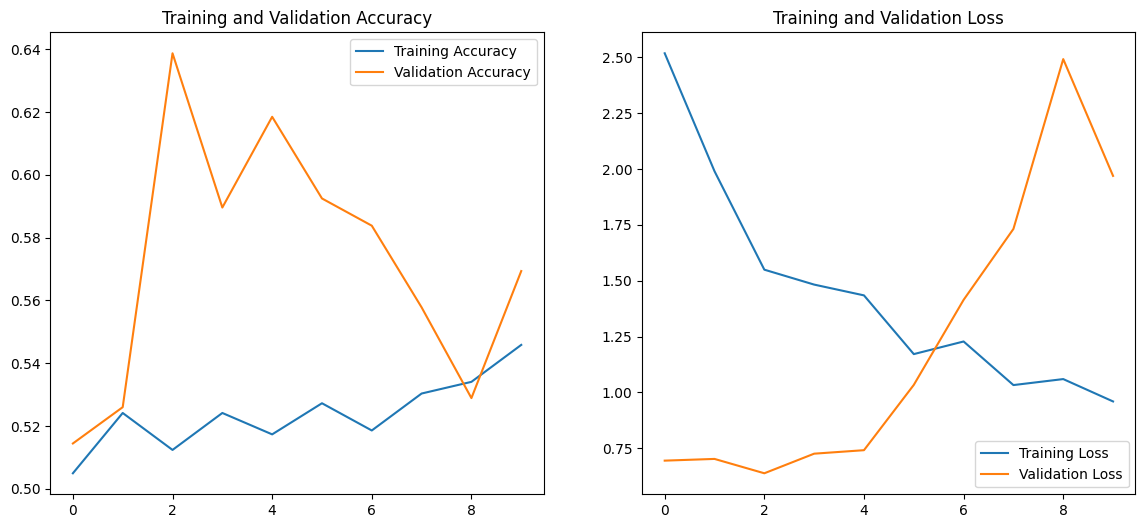

In [20]:
# Plot training metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [21]:
cnn_model.evaluate(x_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6682 - loss: 0.6059


[0.616015613079071, 0.6426513195037842]

In [27]:
y_pred_prob = cnn_model.predict(x_test)

y_pred = (y_pred_prob > 0.45).astype("int32").flatten()

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
              precision    recall  f1-score   support

           0       0.67      0.64      0.66       171
           1       0.67      0.69      0.68       176

    accuracy                           0.67       347
   macro avg       0.67      0.67      0.67       347
weighted avg       0.67      0.67      0.67       347



**Insights:**

The custom convolutional neural network achieved an accuracy of approximately 67% on the test dataset. The precision, recall, and F1-scores are nearly balanced for both classes, indicating that the model predicts men and women with similar reliability and does not exhibit class bias. This result shows that the CNN is able to learn some facial patterns, but the overall performance is limited because the model is trained from scratch on a relatively small dataset, which restricts its ability to extract strong discriminative facial features.

# B. Transfer Learning:-

## 1) MobileNetV2